In [6]:
!pip install -r requeriments.txt

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.1 MB 15.8 MB/s eta 0:00:01
   ------------------ --------------------- 4.2/9.1 MB 15.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.3/9.1 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 11.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 42.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 51.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   ----------

  DEPRECATION: Building 'pylatexenc' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pylatexenc'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [7]:
#Necesary libraries
import numpy as np
import cmath
import networkx as nx
import matplotlib.pyplot as plt
import itertools 
import json

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import transpile
from qiskit.visualization import  plot_histogram
from qiskit.quantum_info import state_fidelity,Statevector,partial_trace
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke,FakeBrisbane,FakeKyoto,FakeOsaka,FakeManilaV2,FakeKyiv
from qiskit.quantum_info import negativity

from qubits import abrir_datos_g, qbits_optimos_g2, cadena_optima, encontrar_subconjuntos_bfs, agregar_qbit_grafo
from qiskit_tools import experimento_3l



C:\Users\victo\anaconda3\Lib\site-packages\samplomatic\__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


In [ ]:
your_api_key = "poner clave api"
your_crn = "poner crn de IB"

from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="nombre de instancia",
    overwrite=True
)

In [8]:
#Necesary functions:

#Create a matrix from Kronecker products of n-1 Identity matrices and 1 Hadamard matrix
def Cbase(n: int,p : int ,im=False ,norm=False ):
    """
    Inputs
    n: number of qubits of the system
    p: position of Haddamard matrix
    im: Boolean to decide if matrix S is applied
    norm: Boolean to decide if H colunms oh H are normalized (for combinatorial purpose only)
    Outputs:
    B: a (2^n)x(2^n) matrix produced by M_0(x).(x)M_j..(x)M_{n-1}, where M_j=Id_2 if j!=p and M_j= (S)^(int(im)) H if j=p
    """
    H=np.array([[1,1],[1,-1]]) #Define Haddamard matrix
    if norm: 
        H=1/np.sqrt(2)*H #Apply normalization for vectors
        
    Id=np.eye(2) # 2x2 identity matrix
    if im:
        S=np.array([[1,0],[0,1j]]) #If complex is implemented, then we define S matrix
        
    else:
        S=Id
    
    if p==1: #Tensor product for application of measurement basis Id is applied on all qubits q_j for j+1!=p 
        B=S@H #If j=p=1 we apply local tranformation S@H 
    else:
        B=Id 
    for j in range(1,n):
        if j+1==p: #Check for j+1=p to apply the desired local operation
            B=np.kron(B,S@H)
        else:
            B=np.kron(B,Id)
    return B

#Pairs of columns for measurements
def cols_pairs(q: int,p :int):
    """
    This function calculates the the pair of columns of a given basis of the set of the 2n bases such that they are used in
    the same polariation identity, i.e., the columns representing (|j>\pm \k>)/sqrt(2) from the basis.
    Inputs:
    q: number of qubits of the system
    p: positions of the Hadamard matrix
    
    Outputs: 
    pairs: a list of paired columns for the measurements operators
    """
    pairs=np.zeros((2**(q-1),2),dtype=int)
    n=q-p
    j=0
    if n==0:
        for col in range(0,2**q):
            if col % 2==0:
                pairs[j,0],pairs[j,1]=col,col+1
                j+=1
    else:
        Ind=np.ones((2**q))
        for col in range(0,2**q-2**n):
            if Ind[col]==1:
                pairs[j,0],pairs[j,1]=col,col+(2**n)
                j+=1
                Ind[col],Ind[col+2**n]=0,0
                
    return pairs

#Adjacency Matrix

def AM(q: int):
    """
    Creates the adjacency matrix for an hyipercubic graph
    Input:
    q: number of qubits.
    Output
    A: adjacency matrix for Hypercube graph of qth grade
    
    """
    if q==1:
        A=np.array([[0,1],[1,0]],dtype=int)
    else:
        A=np.array(np.kron(np.eye(2),AM(q-1))+np.kron(AM(1),np.eye(2**(q-1))),dtype=int)
    
    return A

#Graph creation for hypercubic graph for n qubit system
def create_graph(n:int):
    """
    This function create a hypercubic graph for a n-qubit system
    Input:
    n: qubit number
    Output:
    G: Hypercube graph of degree n (Q_n)
    """
    edges=[]
    A=AM(n)
    
    for i in range(2**n):
        mat=A[i]
        for j in range(2**n):
            if mat[j]==1:
                temp=[i,j]
                edges.append(temp)
    vertices=[i for i in range(n)]
    G=nx.Graph()
    G.add_edges_from(edges)
    return G

#All shorthest path between two nodes
def all_paths(n:int,s:int,t:int):
    """
    Find all paths with the lowest number of edges between nodes s and t of a graph
    Input:
    n: number of qubits
    s: source node
    t: target noude
    Output:
    paths: an array with all paths with the lowest number of edges between  nodes s and t
    """
    paths=[]
    for path in nx.all_shortest_paths(create_graph(n),source=s,target=t):
        paths.append(path)
    return paths


#Shorthest path wich maximes f=Sqrt(Sum(Abs(c_j)^2))
def maxpath(n:int,s:int,t:int, csq: np.array):
    """
    Calculates all paths with the lowest number of edges between nodes s and t of a graph. Then, selects the phat which 
    maximizes f= Sum_{path} |c_j|^2 for j\in Nodes(path)
    Input:
    n: number of qubits
    s: source node
    t: target noude
    csq: vector that contains |c_j|^2 with j=0,...,n-1
    Output:
    maxpath: the path with the maximun f
    """
    paths=all_paths(n,s,t)
    f=np.zeros(len(paths))
    for i,path in enumerate(paths):
        for j in path:
            f[i]+=csq[j]            
    maxpath=paths[np.argmax(f)]
    return maxpath

def all_max_paths(n:int,csq: np.array):
    """
    Calculate all paths that lead to node t from all others such that they maximize f
    Input:
    n: qubit number
    csq:  vector that contains |c_j|^2 with j=0,...,n-1
    Output:
    paths: all paths that lead to node t from all others such that they maximize f
    """
    paths=[]
    t=np.array(csq).argmax()
    for s in range(2**n):
        if s==t:
            pass
        else:
            paths.append(maxpath(n,s,t,csq))
    return paths


#Complete prob vectors with zeros
def full_prob_dist(n:int,pb: dict):
    """
    Fill zeros for an incomplete probability vector, i.e, for n-qubit system returns aa array of 2^n elements containing 
    all the probabilities for the 2^n elements of a basis, includig those with p_j=0
    Input: 
    n: number of qubits
    pb: a dictionary of a p dist from qiskit
    
    Output
    fpb= a fullfilled dictionay with porobability distribution with the null elements considered
    """
    fpb={}
    for i in list(itertools.product(['0','1'], repeat=n)):
        key="".join(i)
        if key in pb:
            fpb.update({key:pb[key]})
        else:
            fpb.update({key:0})
    return fpb

#Dataset post-processing to obtain results in the desired format
def post_process(qc_results : dict, n : int, p :int , im=False ):
    """
    Given that qiskit returns the probability distribution tagged as binary labels of the compuational basis, here we apply
    relabeling of the elements to represent the labels for a different basis from the 2n basis set.
    
    Input:
    qc_results: a dictionaray with the results of a quantum circuit experiment
    n: number of qubits
    p:position of H or SH matrix
    im: Bolean value to indicate if we use H o SH
    
    Output:
    MBs: a dictionay in the disered format for compute results
    """
    B=Cbase(n,p,im) #generate a 2^n x 2^n matrix representing the desired basis
    kwds=[] #array where all labels will be storaged
    for col in range(len(B[0])):
        for nz in np.nonzero(B[:,col]): #find the non null elements within a colum of B
            #print(nz)
            kwd='p_'+str(nz[0])+'_'+str(nz[1]) # Generate the label in the format "p_j_k+" "p_j_k-" "p_j_ki+" "p_j_ki-" for element pair j,k
        if int(np.real(B[nz[1],col]))==-1:
                kwd=kwd+'-'
        elif int(np.imag(B[nz[1],col]))==-1:
                kwd=kwd+'i-'
        elif int(np.imag(B[nz[1],col]))==1:
                kwd=kwd+'i+'
        else:
                kwd=kwd+'+'
        kwds.append(kwd)
        MBs=dict(zip(kwds,list(qc_results.values()))) # Create a dictionary with proper labes asigned to probability distributions
    return MBs

#Determine de weighted adj matrix
def adj_w(n,my_dict):
    """
    Calculates all the polarization identitites and storage them as element of a matrix, a weighted adjacency matrix
    Input:
    n: qubit number
    my_dict= a dictonary with probability distribution for the 2n basis used for the tomography (Computational Basis excluded) 
    Output:
    Aw: Adj matrix with weights
    """
    Aw=np.zeros((2**n,2**n),dtype=complex)
    for i in range(len(Aw[0])):
        for j in range(i+1,len(Aw[0])):
            if 'p_'+str(i)+'_'+str(j)+'+' in my_dict:
                Aw[i,j]+=(my_dict['p_'+str(i)+'_'+str(j)+'+']-my_dict['p_'+str(i)+'_'+str(j)+'-']+
                          (my_dict['p_'+str(i)+'_'+str(j)+'i+']-my_dict['p_'+str(i)+'_'+str(j)+'i-'])*1j)
                Aw[j,i]=np.conjugate(Aw[i,j])
    #print(Aw)
    return Aw


#Determine al the c[i] complex coeficients of qs
def qto(n,Aw,ct):
    """
    Stimates the elemements of a pure quantum state given the a weighted adjacency matrix realted to the 2n+1 bases set
    
    Input:
    n: qubit number
    Aw: Adj matrix with weights
    ct: an array with the prob dist in computacional basis
    Output:
    c: an array with probability amplitudes of the reconstructed state
    """
    c=np.ones(2**n,dtype=complex)
    
    impar=0
    par=1
    #print(all_max_paths(n,ct))
    for path in all_max_paths(n,ct):
        #print(path)
        #print((len(path)-1) % 2==1)
        for j in range(len(path)-1):
            if j%2==0:
                
                c[path[0]]= c[path[0]]*np.conjugate(Aw[path[j],path[j+1]])
                
            else:
    
                c[path[0]]=c[path[0]]/ (Aw[path[j],path[j+1]])
        #print(c[path[0]])    
        if (len(path)-1) % 2==1:            
            impar+=(np.absolute(c[path[0]])**2)
            #print(impar)
        else:
            
            par+=(np.absolute(c[path[0]])**2)
            #print(par)
    #print(c)
    #print(impar)
    #print(par)
    ctilde=np.roots([par,-1,impar/4])
    #print(ctilde)
    c[np.argmax(ct)]=np.sqrt(np.max(ctilde.real))
    
    for path in all_max_paths(n,ct):
        #print(path)
        if (len(path)-1) % 2==1:
            c[path[0]]/=(2*c[np.argmax(ct)])
        else:
            c[path[0]]*=c[np.argmax(ct)]
    return c

def state_3layers(nq: int):
    """
    Entangled state with 3 layers
    input:
        nq= qubit number
    Output:
        qc: quantum circuit with 3 layer state
    """
    qr=QuantumRegister(nq,'qr')
    cr=ClassicalRegister(nq,'cr')
    qc=QuantumCircuit(qr,cr)
    if nq%2==0:
        qc.sx(list(range(nq)))
    else:
        qc.sx(list(range(nq-1)))
        qc.x(nq-1)
    for i in range(0,nq-1,2):
        qc.ecr(i,i+1)
    for i in range(1,nq-1,2):    
        qc.ecr(i,i+1)
    #qcf5.sx(0)
    qc.sx(0)
    #for i in range(1,nq):
    #    qc.sx(i)
    return qc

def state_4layers(nq):
    """
    Entangled state with 4 layers (This was used for the test on Kyoto QPU)
    input:
        nq= qubit number
    Output:
        qc: quantum circuit with 4 layer state
    """
    qr=QuantumRegister(nq,'qr')
    cr=ClassicalRegister(nq,'cr')
    qc=QuantumCircuit(qr,cr)
    qc.sx(list(range(nq)))
    for i in range(0,nq-1,2):
        qc.ecr(i,i+1)
    for i in range(1,nq-1,2):    
        qc.ecr(i,i+1)
    #qcf5.sx(0)
    for i in range(1,nq):
        qc.sx(i)
    return qc


#Circuit Functions
def circuit_cons(nq,pH,primada,qci):
    ################### Args #####################################################################
    """
    This function creates all the circuits to implement the 2n+1 basis method given an initial state qci 
    Input:
    # nq: Qubit number.
    # pH Haddamard gate position.
    # primada: if 0 computational bases, if 1 only H gate is applied, valor 2 apply H Sdagger operations (inverse of SH) 
    # qci: initial state.
    
    Output:
    prop_dist: prob dist the desired state and measurement.
    """
    ########################## Circuit for bases ######################################################
    qr = QuantumRegister(nq, 'Qubit')
    cr = ClassicalRegister(nq, 'Bit')
    qc= QuantumCircuit(qr,cr)  
   
    ########################### Computational basis ################################################
    qr = QuantumRegister(nq, 'Qubit')
    cr = ClassicalRegister(nq, 'Bit')
    cb = QuantumCircuit(qr,cr)  
    
    ########################### Resultado Base computacional ################################################
    if primada == 0: 
        cb.measure(range(nq),range(nq))
        combined  = qci.compose(cb)       
        return combined
    ###########################################################################################################
    elif primada == 1:
        if pH <= nq:  
            cb.h(nq-pH) # as Qiskit counts from right to left we need to change position of H gate
            
            cb.measure(qr,cr)            
            combined = qci.compose(cb)
            return combined

    elif primada == 2:
        if pH <= nq:
            cb.sdg(nq-pH)
            cb.h(nq-pH)
            cb.measure(qr,cr)
            combined = qci.compose(cb)
            return combined
    else:
        print(f'ERROR look qubit number, H position, primada value or initial state')
        
def ideal_coupling(nq,qc,init_layout,my_backend='ibm_sherbrooke'):
    """
    Given an initial layout for qubits, choose the best ordering for the layout.
    
    Input: 
    nq: qubit number
    qc: Quantum circuit of nq qubits
    my_backend: Objective Hardware
    init_layout: Best qubit set to implement the circuit (without considering coupling directions)
    Output:
    final_layout: best qubit set to implement the circuit with best dcoupling direcction.
    """
    simulator=service.backend(my_backend)
    reversed_layout=list(reversed(init_layout))
    #qc= Init_state_native_gates(nq)
    
    pm_i=generate_preset_pass_manager(optimization_level=3, 
                                      initial_layout=init_layout,
                                      approximation_degree=0.99,
                                      backend=simulator,
                                      seed_transpiler=12345)
    qc_i= pm_i.run(qc)
    
    pm_r=generate_preset_pass_manager(optimization_level=3, 
                                      initial_layout=reversed_layout,
                                      approximation_degree=0.99,
                                      backend=simulator,
                                      seed_transpiler=12345)
    
    qc_r=pm_r.run(qc)
    
    if qc_i.depth()<qc_r.depth():
        return init_layout
    else:
        return reversed_layout
    
def merge_dicts_from_ids(job_ids,service):
    """
    Create an array of dictionaries from results of IBM experiments:
    
    Input: 
    job_ids: an array of jobs ids
    
    Output:
    sim_result: array of dictionaries with simulations results.
    """
    sim_result=[]
    
    for job_id in job_ids:
        #print(job_id)
        temp_job=service.job(job_id)
        for counts in temp_job.result():
            sim_result.append(counts.data.cr.get_counts())
    return sim_result

#The Final Functions
def measurements(n,ns,qci,my_backend,init_layout,computational=True,bases=0):
    """
    This function is used to run an experiment on IBM platform
    Input
    n: number of qubits
    ns: shot number
    qci:initial state
    my_backend: Str with quantum divice to be used, format 'ibm_'+device_name
    init_layout: layout proposal
    bases: integer array with Hadamard positions for mesaruemestas
    Output:
        state: a dictionary with the estimated state
        
    """
    backend=service.backend(my_backend)
    sampler = Sampler(mode=backend)        
    final_layout=ideal_coupling(nq,qci,init_layout,my_backend)
    pm=generate_preset_pass_manager(optimization_level=3,initial_layout=final_layout,approximation_degree=0.99,backend=backend,seed_transpiler=12345)

    
    
    qc_all_bases=[]
    if computational:
        qc=circuit_cons(n,0,0,qci)
        qc_all_bases.append(pm.run(qc))
    config=[]
    
    if bases==0:
        bases=list(range(1,n+1))
        
    for pH in bases:
        for primada in [1,2]:
            qc=circuit_cons(n,pH,primada,qci)
            #qc_all_bases.append(transpile(qc,simulator,optimization_level=3))
            #pm=generate_preset_pass_manager(optimization_level=3,initial_layout=final_layout, approximation_degree=0.99,backend=simulator,seed_transpiler=12345)
            qc_all_bases.append(pm.run(qc))
            config.append([pH,primada])
            #print(config[-1])
            #print(qc)
    
    job_sim = sampler.run(qc_all_bases,shots=ns)
    #job_sim = simulator.run(qc_all_bases,shots=ns)
    #sim_result =job_sim.result().get_counts()
    #return sim_result
    #return job_sim,qc_all_bases
    return job_sim


def q_tomo_sim_results(n,ns, sim_result):
    """
    Tomography using previous experimental results
    Input:
    - nq: number of qubits
    - ns: number of shots
    - sim_results: dictionary with results from ALL measurements for nq qubits
    - 
    """
    
    #job_sim=service.job(job_id)
    #sim_result
    
    #perform measuremts on computational basis
    #csq=circuit_cons(n,1,0,qci)
    #Complete the prob dist
    csq=full_prob_dist(n,sim_result[0])
    #print(csq)
    #Dict for storage measures
    pds={}
    
    config=[]
    for pH in range(1,n+1):
        for primada in [1,2]:
            config.append([pH,primada])
            #print(config[-1])
            #print(qc)
    
    #Post proecessing of measurements
    for i in range(0,len(config)):
        #Complete the prob dist
        #print(config[i])
        #print(sim_result[i+1])
        mb=full_prob_dist(n,sim_result[i+1])
        mb={k: v / ns for k, v in mb.items()}
        pH,primada=config[i]
        #save measuremets in format
        pds.update(post_process(mb,n,pH,primada==2))
        #pds=dict(sorted(pds.items()))       
        #Weighted Hermitian Adjacency matrix
    #print(pds)
    Aw= adj_w(n,pds)       
    #optimal paths
    csqv=list(csq.values())
    state=qto(n,Aw,csqv)
    state=state/np.linalg.norm(state)
    phases=[]
    for i in range(len(state)):
        phases.append(cmath.phase(state[i]))
    #return Aw
    #return csq
    #return pds
    #print(csq)
    f_state=[]
    for i in range(len(state)):
        f_state.append(np.sqrt(csqv[i])*np.exp(1j*phases[i]))
    f_state=f_state/np.linalg.norm(f_state)
    return f_state,csq,pds,phases

In [12]:
Statevector(state_4layers(4))

Statevector([-0.1767767-0.1767767j, -0.1767767+0.1767767j,
              0.1767767-0.1767767j,  0.1767767+0.1767767j,
              0.1767767-0.1767767j,  0.1767767+0.1767767j,
              0.1767767+0.1767767j,  0.1767767-0.1767767j,
              0.1767767-0.1767767j,  0.1767767+0.1767767j,
              0.1767767+0.1767767j,  0.1767767-0.1767767j,
             -0.1767767-0.1767767j, -0.1767767+0.1767767j,
              0.1767767-0.1767767j,  0.1767767+0.1767767j],
            dims=(2, 2, 2, 2))


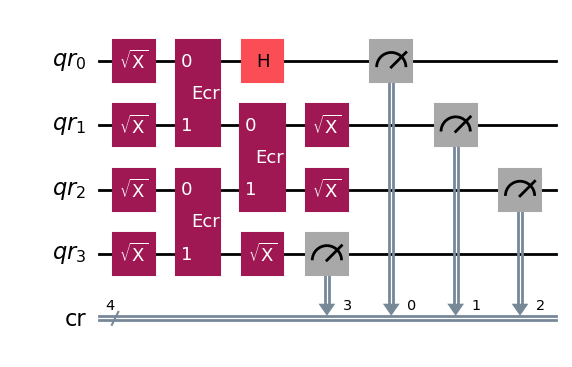

In [22]:
circuit_cons(4,4,1,state_4layers(4)).draw('mpl')

# ExecutionExamples

## Qubit selection 

In [24]:
#print("Choose gates to minimize error, for Eagle r3 quantum processors:")
#print("[0] ECR_error")
#print("[1] REA_error")
#print("[2] RZ_error")
#print("[3] SX_error")
#print("[4] X_error")

"""
This block is used to find the best qubits to run the circuit
"""
from qubits import abrir_datos_g, qbits_optimos_g2, cadena_optima, encontrar_subconjuntos_bfs, agregar_qbit_grafo
from qiskit_tools import experimento_3l
n_q=4
N_Q=12
try:
    #    errores = input("De forma (0,2,4) por ejemplo: ")
    errores = '(0,1,3)'
    errores = [int(x) for x in errores.strip('()').split(',')]
    #print(errores)
except:
    print("formato invalido")
    
my_backend='ibm_sherbrooke'
print(my_backend[4:].title())# print backend name
G = abrir_datos_g(my_backend+".csv", errores, direccionado=True)# it is recommended to update my_backend+".csv" archive before execuing

qubit_list = list()
for i in range(n_q, N_Q + 1):
    qubit_list.append(cadena_optima(encontrar_subconjuntos_bfs(G, i), (my_backend)))
print(qubit_list)


Sherbrooke
para 4 qbits, [126, 125, 124, 123], 0.0003389110515870166
para 5 qbits, [63, 64, 54, 45, 46], 0.00041880421675544264
para 6 qbits, [126, 125, 124, 123, 122, 111], 0.0005507628075163417
para 7 qbits, [125, 124, 123, 122, 111, 104, 103], 0.000598673598678216
para 8 qbits, [126, 125, 124, 123, 122, 111, 104, 103], 0.0006145538757948979
para 9 qbits, [112, 126, 125, 124, 123, 122, 111, 104, 103], 0.0007506597277437184
para 10 qbits, [108, 112, 126, 125, 124, 123, 122, 111, 104, 103], 0.0007700762783009132
para 11 qbits, [107, 108, 112, 126, 125, 124, 123, 122, 111, 104, 103], 0.0009062316100823692
para 12 qbits, [106, 107, 108, 112, 126, 125, 124, 123, 122, 111, 104, 103], 0.0009299896361708955
[[126, 125, 124, 123], [63, 64, 54, 45, 46], [126, 125, 124, 123, 122, 111], [125, 124, 123, 122, 111, 104, 103], [126, 125, 124, 123, 122, 111, 104, 103], [112, 126, 125, 124, 123, 122, 111, 104, 103], [108, 112, 126, 125, 124, 123, 122, 111, 104, 103], [107, 108, 112, 126, 125, 124, 123

## Initial state circuit construction

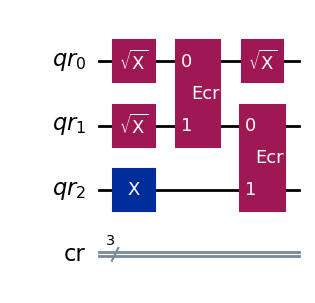

In [13]:
#3 layers
n_q=3
qc_test_3_layers=state_3layers(n_q)
qc_test_3_layers.draw('mpl')

In [40]:
State_3_layers=Statevector(qc_test_3_layers)
State_3_layers.draw('latex')

<IPython.core.display.Latex object>

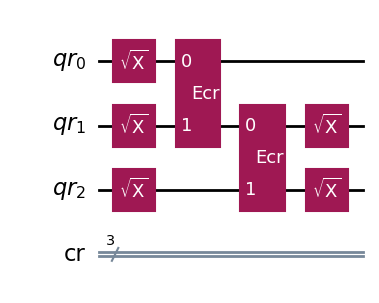

In [41]:
#4 layers
n_q=3
qc_test_4_layers=state_4layers(n_q)
qc_test_4_layers.draw('mpl')

In [42]:
State_4_layers=Statevector(qc_test_4_layers)
State_4_layers.draw('latex')

<IPython.core.display.Latex object>

## Experiment on IBM

In [30]:
#System configuration for execution
my_backend="ibm_brisbane" #Backend (QPU)

nq=4      #Qubit number

ns=20000 #Shot Number

cb_measure=True #need to measure on computational basis

bases=0 #Array with subset of positions for Haddamard matrix measurements. If base=0 mesaure on all possible positions

qci=state_3layers(nq) #State preparation

init_layout=qubit_list[nq-len(qubit_list[0])] #best qubit subset

job_3ly=measurements(nq,ns,qci,my_backend,init_layout,cb_measure,bases) #Measurements on desired bases

id_to_extarct=job_3ly.job_id() #job id from IBM



In [34]:
job_3ly.status()

'DONE'

# Saving the results

In [35]:
#Save results on an archive
"""
Once the Job if finished on IBM platform, we need to import job results and save on local device
"""
ts_job=service.job(id_to_extarct)
sim_result=[]
for counts in ts_job.result():
    sim_result.append(counts.data.cr.get_counts())

file_title='res_'+my_backend[4:]+'_'+str(nq)+'_test.txt'    
    
with open('res_'+my_backend[4:]+'_'+str(nq)+'.txt', 'w') as filehandle:
    json.dump(sim_result, filehandle)


## Read data from IonQ

In [23]:
import pandas as pd

In [108]:
df_tomo_chile=pd.read_csv('simulator_oxford_4q_10000shots.csv')

In [109]:
df_tomo_chile['bitstring']=df_tomo_chile['bitstring'].astype(str)

In [110]:
b_comp=df_tomo_chile[df_tomo_chile['basis']=='computational'][['bitstring','probability']]

In [111]:
b_comp=df_tomo_chile[df_tomo_chile['basis']=='computational'][['bitstring','probability']]
b_comp['bitstring']=b_comp['bitstring'].map(lambda x: ('0'*(4-len(x)))+x)
#(dict(zip(b_comp['bitstring'].unique(),(b_comp['probability']*10000).unique().astype(int)))

_IncompleteInputError: incomplete input (3189363613.py, line 3)

In [112]:
data_base['probability']=(data_base['probability']*10000).astype(int)

In [61]:
(b_comp['probability']*10000).unique().astype(int)

array([601, 653, 633, 689, 713, 608, 590, 625, 640, 624, 583, 650, 591,
       612, 580])

In [ ]:
(dict(zip(b_comp['bitstring'].unique(),(b_comp['probability']*10000).unique().astype(int)))

In [ ]:
data_formated

In [113]:
ns=10000
data_formated=[]

b_comp=df_tomo_chile[df_tomo_chile['basis']=='computational'][['bitstring','probability']]
b_comp['bitstring']=b_comp['bitstring'].map(lambda x: ('0'*(4-len(x)))+x)

 
data_formated.append((dict(zip(b_comp['bitstring'].unique(),(b_comp['probability']*10000).unique().astype(int)))))
for b_index in range(0,4):
    for b_g in ['x','y']:
        base=b_g+'_'+str(b_index)
        data_base=df_tomo_chile[df_tomo_chile['basis']==base].copy()
        data_base['bitstring']=data_base['bitstring'].map(lambda x: ('0'*(4-len(x)))+x)
        data_base['probability']=(data_base['probability']*ns).astype(int)
        data_formated.append(dict(zip(data_base['bitstring'].unique(),(data_base['probability']).unique().astype(int))))



In [115]:
res_tmp=q_tomo_sim_results(4,10000,data_formated)

qci=QuantumCircuit(4,4)
qci.ry(np.pi/2,0)
qci.ry(np.pi/2,1)
qci.ry(np.pi/2,2)
qci.ry(np.pi/2,3)

qci.rzz(np.pi/2,0,1)
qci.rzz(np.pi/2,2,3)
qci.rzz(np.pi/2,1,2)

qci.draw('mpl')


state_fidelity(Statevector(res_tmp[0]),Statevector(qci))

0.3070596871625305

In [90]:
res_tmp[0]

array([-2.52915159e-01+4.95507250e-03j,  2.63117520e-01+1.72170818e-02j,
        2.59591590e-01-3.16093234e-03j,  2.69408504e-01-2.79170979e-02j,
        2.75527989e-01+0.00000000e+00j, -1.70702218e-01-1.88670873e-01j,
        2.42076944e-01-6.49474726e-02j, -2.24091410e-02+2.56989936e-01j,
       -7.00979012e-02+2.51454538e-01j, -1.81056232e-02+2.57121974e-01j,
       -5.38522058e-02+2.43257159e-01j,  1.64331888e-02+2.62560063e-01j,
       -2.50850343e-01+3.07203069e-17j,  1.87646965e-01-1.73062001e-01j,
        1.52165365e-17+2.48504899e-01j,  0.00000000e+00+0.00000000e+00j])

In [91]:

state_fidelity(Statevector(state),Statevector(res_tmp[0])))

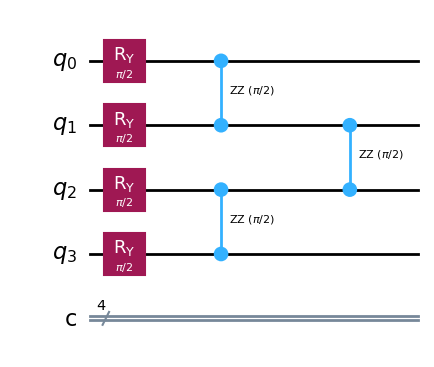

In [101]:
qci=QuantumCircuit(4,4)
qci.ry(np.pi/2,0)
qci.ry(np.pi/2,1)
qci.ry(np.pi/2,2)
qci.ry(np.pi/2,3)

qci.rzz(np.pi/2,0,1)
qci.rzz(np.pi/2,2,3)
qci.rzz(np.pi/2,1,2)

qci.draw('mpl')

# Tomographic protocol from saved data

In [5]:
#Example for tomography protocol aplication using storaged results for Kyoto

ns=20000
for nq in range(3,10):
    state=state_4layers(nq)
    with open(f'res_kyoto_{nq}.txt') as f:
        sim_res = json.load(f)
    #sim_res=test_job.result().get_counts()
    res_tmp=q_tomo_sim_results(nq,ns,sim_res)
    print(f'Kyoto {nq} qubits: ',state_fidelity(Statevector(state),Statevector(res_tmp[0])))

Kyoto 3 qubits:  0.9916208837726312
Kyoto 4 qubits:  0.9970662957598613
Kyoto 5 qubits:  0.9899326476233214
Kyoto 6 qubits:  0.9868714214177463
Kyoto 7 qubits:  0.9792535502081341
Kyoto 8 qubits:  0.9137075866163898
Kyoto 9 qubits:  0.87844709863117


In [10]:
#Example for tomography protocol aplication using storaged results For Sherbrooke

#ns=20000
for nq in range(3,10):
    if nq<10:
        ns=20000
    elif nq <12:
        ns=40000
    else:
        ns=80000
    state=state_3layers(nq)
    with open(f'res_sherbrooke_{nq}.txt') as f:
        sim_res = json.load(f)
    #sim_res=test_job.result().get_counts()
    res_tmp=q_tomo_sim_results(nq,ns,sim_res)
    print(f'Sherbrooke {nq} qubits: ',state_fidelity(Statevector(state),Statevector(res_tmp[0])))

Sherbrooke 3 qubits:  0.9872727878519171
Sherbrooke 4 qubits:  0.9836217803257756
Sherbrooke 5 qubits:  0.9889855203101146
Sherbrooke 6 qubits:  0.9854302478943172
Sherbrooke 7 qubits:  0.9706740894603926
Sherbrooke 8 qubits:  0.9462625514392954
Sherbrooke 9 qubits:  0.9271965193370836


In [11]:
#Example for tomography protocol aplication using storaged results For Kyiv

#ns=20000
for nq in range(3,10):
    if nq<10:
        ns=20000
    elif nq <12:
        ns=40000
    else:
        ns=80000
    state=state_3layers(nq)
    with open(f'res_kyiv_{nq}.txt') as f:
        sim_res = json.load(f)
    #sim_res=test_job.result().get_counts()
    res_tmp=q_tomo_sim_results(nq,ns,sim_res)
    print(f'Kyiv {nq} qubits: ',state_fidelity(Statevector(state),Statevector(res_tmp[0])))

Kyiv 3 qubits:  0.986726311461195
Kyiv 4 qubits:  0.9970002882002368
Kyiv 5 qubits:  0.9919685302791336
Kyiv 6 qubits:  0.9837681427930567
Kyiv 7 qubits:  0.9799983491567625
Kyiv 8 qubits:  0.9246338455547208
Kyiv 9 qubits:  0.8306951642269923
